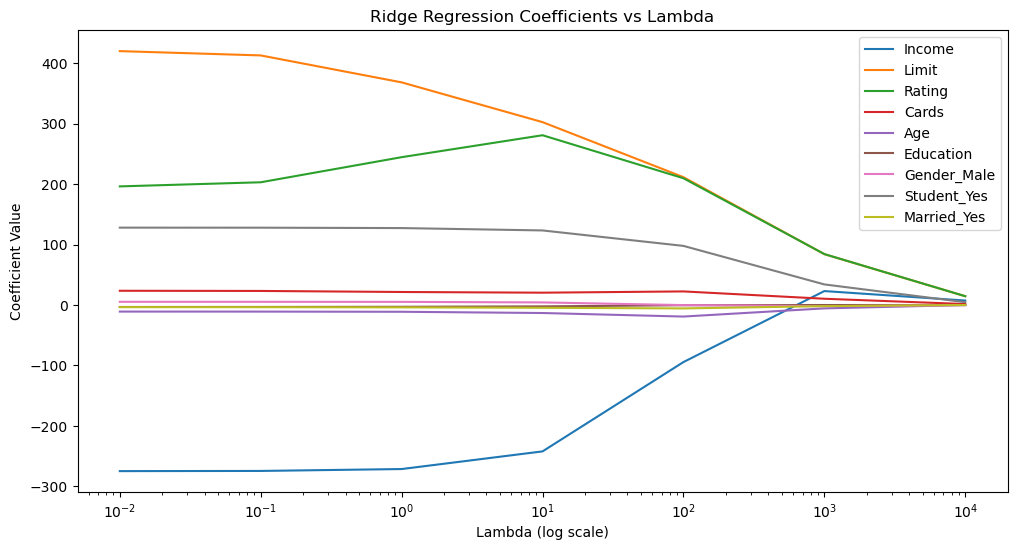

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold

# Load the data
data = pd.read_csv(r"C:\Users\victo\OneDrive\Documentos\DATA SCIENCE AND ANALYTICS\FULL 2024\Computational Foundations AI\Credit_N400_p9.csv")

# Include all features
X = data[['Income', 'Limit', 'Rating', 'Cards', 'Age', 'Education', 'Gender', 'Student', 'Married']]
y = data['Balance'].values

# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, columns=['Gender', 'Student', 'Married'], drop_first=True)

# Standardize all features
X_standardized = (X_encoded - X_encoded.mean()) / X_encoded.std()

# Convert to numpy array
X_array = X_standardized.values
y_centered = y - np.mean(y)

def ridge_regression(X, y, lambda_val, learning_rate, num_iterations):
    num_samples, num_features = X.shape
    beta = np.random.uniform(-1, 1, num_features)
    
    for _ in range(num_iterations):
        predictions = X.dot(beta)
        gradient = -2 * X.T.dot(y - predictions) + 2 * lambda_val * beta
        beta -= learning_rate * gradient
    
    return beta

# Define lambda values
lambda_values = [10**i for i in range(-2, 5)]

coefficients = []
for lambda_val in lambda_values:
    beta = ridge_regression(X_array, y_centered, lambda_val, learning_rate=1e-5, num_iterations=100000)
    coefficients.append(beta)

plt.figure(figsize=(12, 6))
feature_names = X_encoded.columns
for i, feature_name in enumerate(feature_names):
    plt.semilogx(lambda_values, [coef[i] for coef in coefficients], label=feature_name)

plt.xlabel('Lambda (log scale)')
plt.ylabel('Coefficient Value')
plt.title('Ridge Regression Coefficients vs Lambda')
plt.legend()
plt.show()

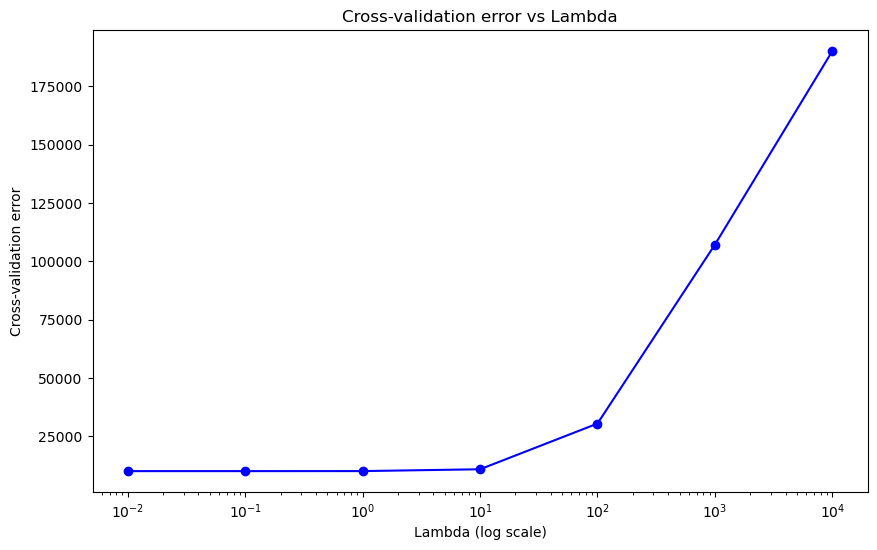

In [52]:
def cross_validate(X, y, lambda_val, learning_rate, num_iterations):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_errors = []
    
    for train_index, val_index in kf.split(X):
        X_train, X_val = X[train_index], X[val_index]
        y_train, y_val = y[train_index], y[val_index]
        
        beta = ridge_regression(X_train, y_train, lambda_val, learning_rate, num_iterations)
        
        predictions = X_val.dot(beta)
        mse = np.mean((y_val - predictions)**2)
        cv_errors.append(mse)
    
    return np.mean(cv_errors)

cv_errors = []
for lambda_val in lambda_values:
    cv_error = cross_validate(X_array, y_centered, lambda_val, learning_rate=1e-5, num_iterations=100000)
    cv_errors.append(cv_error)

plt.figure(figsize=(10, 6))
plt.semilogx(lambda_values, cv_errors, 'bo-')
plt.xlabel('Lambda (log scale)')
plt.ylabel('Cross-validation error')
plt.title('Cross-validation error vs Lambda')
plt.show()

In [61]:
best_lambda = lambda_values[np.argmin(cv_errors)]
print(f"Best lambda: {best_lambda}")

Best lambda: 0.1


In [59]:
final_beta = ridge_regression(X_array, y_centered, best_lambda, learning_rate=1e-5, num_iterations=100000)

feature_names = X_encoded.columns
print("Final model coefficients:")
for name, coef in zip(feature_names, final_beta):
    print(f"{name}: {coef}")

Final model coefficients:
Income: -274.68831641326057
Limit: 412.87143737661916
Rating: 203.09291607531432
Cards: 23.1814169520425
Age: -11.009921984040307
Education: -3.3096867192731074
Gender_Male: 5.197848623735954
Student_Yes: 127.86266917776307
Married_Yes: -3.653103623037321
